      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 e

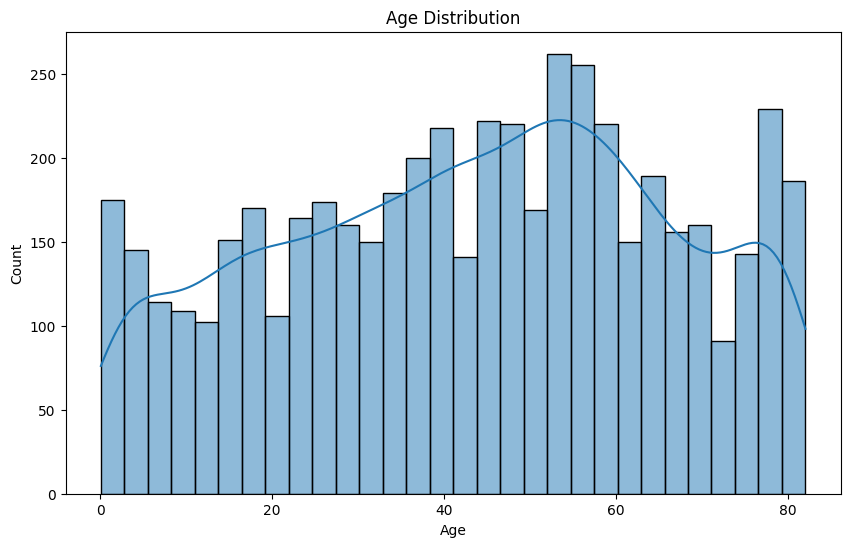

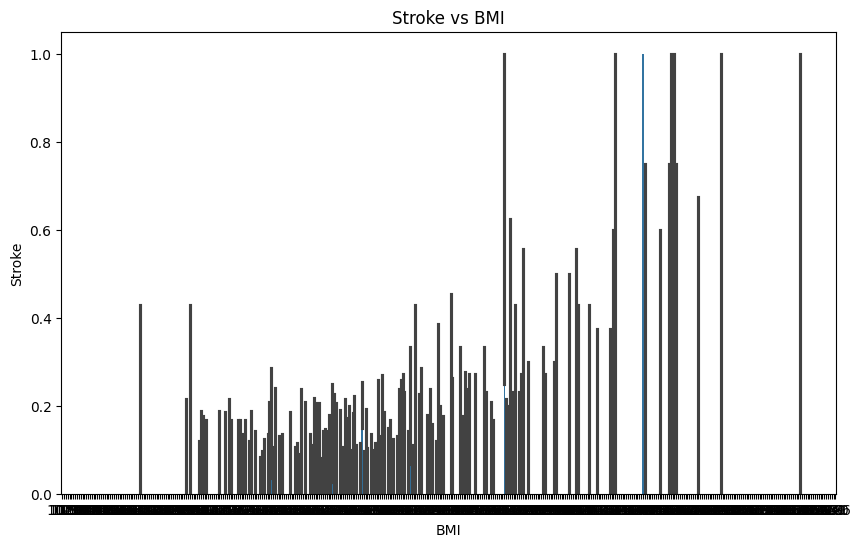

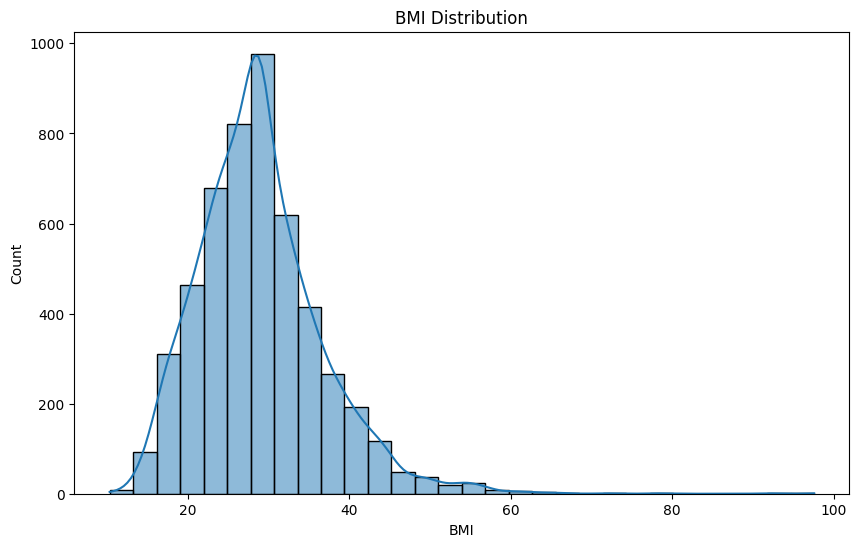

Confusion Matrix:
[[882 334]
 [ 13  49]]


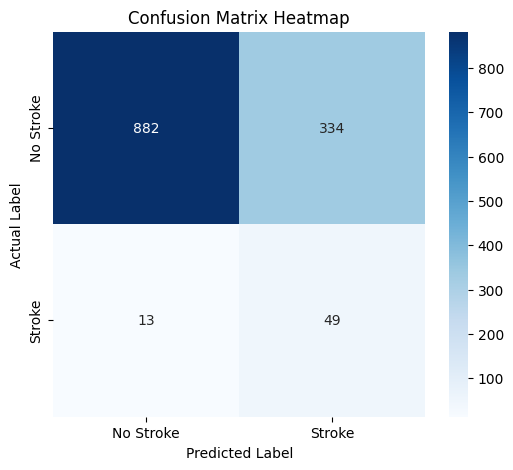

Accuracy Score:
0.7284820031298904
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1216
           1       0.13      0.79      0.22        62

    accuracy                           0.73      1278
   macro avg       0.56      0.76      0.53      1278
weighted avg       0.94      0.73      0.81      1278

Logistic Regression Coefficients:
                           Feature  Coefficient  Absolute_Coefficient
0                              age     1.878491              1.878491
11              work_type_children     0.392615              0.392615
3                avg_glucose_level     0.219692              0.219692
8           work_type_Never_worked    -0.156511              0.156511
1                     hypertension     0.155445              0.155445
15           smoking_status_smokes     0.154411              0.154411
10         work_type_Self-employed    -0.116556              0.116556
5                    

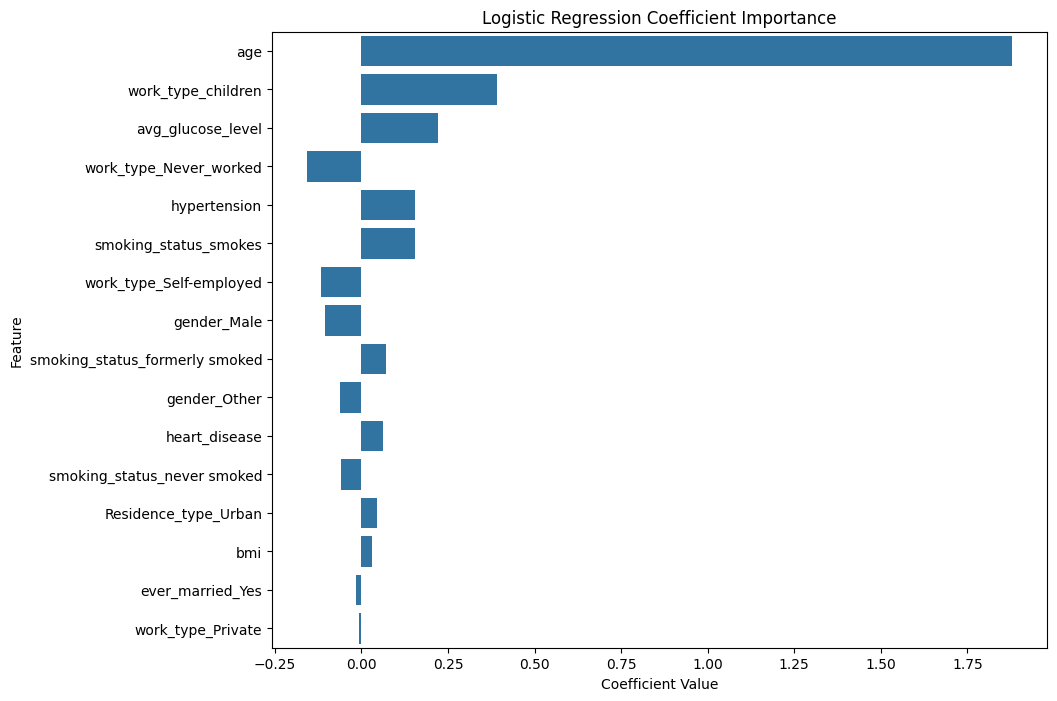

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('healthcare_dataset_stroke_data.csv')

# View first few rows
print(data.head())

# Check dataset structure
print(data.info())

# Check missing values before cleaning
print(data.isnull().sum())

# Replace missing BMI values with the mean BMI
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

# Confirm missing values were handled
print(data.isnull().sum())

# Summary statistics for numeric variables
print(data.describe())

# Encode categorical variables into numeric dummy variables
data = pd.get_dummies(
    data,
    columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],
    drop_first=True
)

# View updated dataset after encoding
print(data.head())

# Define independent variables and dependent variable
x = data.drop(columns=['id', 'stroke'])
y = data['stroke']

# Age Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Stroke vs BMI Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='bmi', y='stroke')
plt.title('Stroke vs BMI')
plt.xlabel('BMI')
plt.ylabel('Stroke')
plt.show()

# BMI Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Scale the independent variables
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Create logistic regression model with balanced class weights
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Fit model
model.fit(x_train_scaled, y_train)

# Make predictions
y_pred = model.predict(x_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Accuracy score
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Logistic Regression Coefficient Importance Chart
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("Logistic Regression Coefficients:")
print(coefficients)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)
plt.title('Logistic Regression Coefficient Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()